# Neurona manual con NumPy sobre MNIST

## Objetivo

Implementar desde cero un clasificador binario lineal —equivalente a una neurona con activación sigmoide o a una regresión logística— y estudiar dos problemas:

1. MNIST **0 vs 1**.
2. MNIST **5 vs 6**.

El notebook hace explícitos *forward*, coste, gradientes y actualización. No es una red profunda. La selección del *learning rate* utiliza exclusivamente validation y test se evalúa una única vez al final de cada experimento.

> Instalación: usa `tema-02-machine-learning/requirements/common.txt`. Este notebook no instala paquetes durante la ejecución.

## 1. Configuración reproducible y modo de ejecución

- `RUN_MODE=fast`: smoke test con subconjuntos y pocas épocas; `publishable: false`.
- `RUN_MODE=full`: entrenamiento completo; `publishable: true` si termina y pasa las validaciones.

In [1]:
import gzip
import json
import os
import platform
import struct
import subprocess
import sys
import time
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

RUN_MODE = os.getenv("RUN_MODE", "full").lower()
if RUN_MODE not in {"fast", "full"}:
    raise ValueError("RUN_MODE debe ser 'fast' o 'full'")

SEED = 42
np.random.seed(SEED)


def localizar_tema2() -> Path:
    cwd = Path.cwd().resolve()
    candidatos = [cwd, cwd / "tema-02-machine-learning", *cwd.parents]
    for candidato in candidatos:
        if candidato.name == "tema-02-machine-learning" and (candidato / "AGENTS.md").exists():
            return candidato
    raise FileNotFoundError("No se pudo localizar la raíz tema-02-machine-learning")


TEMA2_ROOT = localizar_tema2()
DATA_DIR = TEMA2_ROOT / ".data" / "mnist"
RESULTS_ROOT = (
    TEMA2_ROOT
    / "02-deep-learning-redes-neuronales"
    / "results"
    / "01_neurona_manual_numpy_mnist"
)
RUN_DIR = RESULTS_ROOT / "experiments" / RUN_MODE
DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

PUBLISHABLE = RUN_MODE == "full"
print(f"RUN_MODE={RUN_MODE} | publishable={str(PUBLISHABLE).lower()}")
print(f"Dispositivo: CPU | semilla: {SEED}")
print(f"Datos: {DATA_DIR}")

RUN_MODE=full | publishable=true
Dispositivo: CPU | semilla: 42
Datos: C:\Users\rbenitez\Documents\Master IA\master-ia-agentica\tema-02-machine-learning\.data\mnist


## 2. Dataset MNIST

MNIST contiene imágenes de dígitos de 28×28 píxeles. Se descargan los cuatro archivos IDX oficiales desde un espejo público y se almacenan en el caché común `.data/mnist`, excluido de Git.

In [2]:
MNIST_URLS = {
    "train-images-idx3-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}


def descargar_si_falta(nombre: str, url: str) -> Path:
    destino = DATA_DIR / nombre
    if not destino.exists():
        print(f"Descargando {nombre}...")
        temporal = destino.with_suffix(destino.suffix + ".tmp")
        urllib.request.urlretrieve(url, temporal)
        temporal.replace(destino)
    return destino


def leer_imagenes_idx(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as archivo:
        magic, cantidad, filas, columnas = struct.unpack(">IIII", archivo.read(16))
        if magic != 2051:
            raise ValueError(f"Magic number inválido para imágenes: {magic}")
        datos = np.frombuffer(archivo.read(), dtype=np.uint8)
    return datos.reshape(cantidad, filas, columnas)


def leer_etiquetas_idx(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as archivo:
        magic, cantidad = struct.unpack(">II", archivo.read(8))
        if magic != 2049:
            raise ValueError(f"Magic number inválido para etiquetas: {magic}")
        datos = np.frombuffer(archivo.read(), dtype=np.uint8)
    if len(datos) != cantidad:
        raise ValueError("Cantidad de etiquetas inconsistente")
    return datos


archivos = {nombre: descargar_si_falta(nombre, url) for nombre, url in MNIST_URLS.items()}
X_train_original = leer_imagenes_idx(archivos["train-images-idx3-ubyte.gz"])
y_train_original = leer_etiquetas_idx(archivos["train-labels-idx1-ubyte.gz"])
X_test_original = leer_imagenes_idx(archivos["t10k-images-idx3-ubyte.gz"])
y_test_original = leer_etiquetas_idx(archivos["t10k-labels-idx1-ubyte.gz"])

print("Train original:", X_train_original.shape, y_train_original.shape)
print("Test original :", X_test_original.shape, y_test_original.shape)

Train original: (60000, 28, 28) (60000,)
Test original : (10000, 28, 28) (10000,)


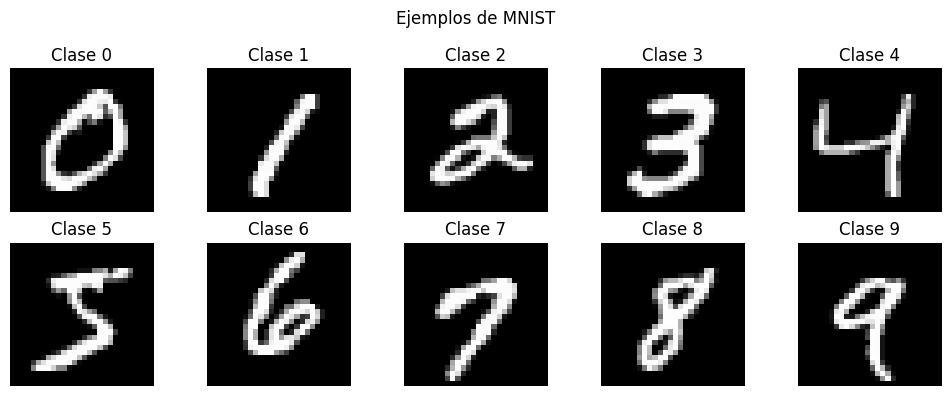

,cantidad
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digito, ax in enumerate(axes.ravel()):
    indice = np.flatnonzero(y_train_original == digito)[0]
    ax.imshow(X_train_original[indice], cmap="gray")
    ax.set_title(f"Clase {digito}")
    ax.axis("off")
plt.suptitle("Ejemplos de MNIST")
plt.tight_layout()
plt.show()

distribucion = pd.Series(y_train_original).value_counts().sort_index()
display(distribucion.rename("cantidad").to_frame())

## 3. Política train, validation y test

Para cada par de dígitos se filtra el train oficial y se divide de forma estratificada en train y validation. El test oficial permanece aislado hasta seleccionar el learning rate y la mejor época.

In [4]:
def limitar_estratificado(X, y, limite, semilla):
    if limite is None or len(y) <= limite:
        return X, y
    X_sub, _, y_sub, _ = train_test_split(
        X, y, train_size=limite, stratify=y, random_state=semilla
    )
    return X_sub, y_sub


def preparar_experimento(clase_negativa, clase_positiva):
    mascara_train = np.isin(y_train_original, [clase_negativa, clase_positiva])
    mascara_test = np.isin(y_test_original, [clase_negativa, clase_positiva])

    X_base = X_train_original[mascara_train]
    y_base = (y_train_original[mascara_train] == clase_positiva).astype(np.int64)
    X_test = X_test_original[mascara_test]
    y_test = (y_test_original[mascara_test] == clase_positiva).astype(np.int64)

    X_train, X_val, y_train, y_val = train_test_split(
        X_base,
        y_base,
        test_size=0.20,
        stratify=y_base,
        random_state=SEED,
    )

    if RUN_MODE == "fast":
        X_train, y_train = limitar_estratificado(X_train, y_train, 1200, SEED)
        X_val, y_val = limitar_estratificado(X_val, y_val, 300, SEED + 1)
        X_test, y_test = limitar_estratificado(X_test, y_test, 500, SEED + 2)

    def normalizar_aplanar(datos):
        return (datos.reshape(len(datos), -1).astype(np.float32) / 255.0)

    return {
        "X_train_img": X_train,
        "X_val_img": X_val,
        "X_test_img": X_test,
        "X_train": normalizar_aplanar(X_train),
        "X_val": normalizar_aplanar(X_val),
        "X_test": normalizar_aplanar(X_test),
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }


for par in [(0, 1), (5, 6)]:
    datos = preparar_experimento(*par)
    print(
        f"{par[0]} vs {par[1]} → "
        f"train={len(datos['y_train'])}, validation={len(datos['y_val'])}, test={len(datos['y_test'])}"
    )

0 vs 1 → train=10132, validation=2533, test=2115
5 vs 6 → train=9071, validation=2268, test=1850


## 4. Neurona binaria implementada manualmente

Para una entrada $x$, la neurona calcula $z = xw + b$ y $p = \sigma(z)$. La pérdida logística se implementa como `logaddexp(0, z) - y*z`, formulación estable que evita `log(0)` y overflow de la sigmoide.

Los gradientes se derivan explícitamente:

$$\nabla_w = X^T(p-y)/m, \qquad \nabla_b = \operatorname{media}(p-y)$$

In [5]:
def sigmoide_estable(z):
    return np.exp(-np.logaddexp(0.0, -z))


def perdida_logistica(logits, y):
    return float(np.mean(np.logaddexp(0.0, logits) - y * logits))


class NeuronaBinariaNumPy:
    def __init__(self, n_features, semilla=42):
        self.w = np.zeros(n_features, dtype=np.float32)
        self.b = np.float32(0.0)
        self.semilla = semilla
        self.history = []
        self.best_epoch = 0

    def predict_proba(self, X):
        return sigmoide_estable(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(np.int64)

    def fit(self, X_train, y_train, X_val, y_val, learning_rate, epochs, batch_size):
        rng = np.random.default_rng(self.semilla)
        mejor_val_loss = np.inf
        mejor_estado = None

        for epoch in range(1, epochs + 1):
            indices = rng.permutation(len(y_train))
            for inicio in range(0, len(indices), batch_size):
                lote = indices[inicio : inicio + batch_size]
                Xb, yb = X_train[lote], y_train[lote]
                probabilidades = self.predict_proba(Xb)
                error = probabilidades - yb
                grad_w = Xb.T @ error / len(lote)
                grad_b = error.mean()
                self.w -= learning_rate * grad_w.astype(np.float32)
                self.b -= np.float32(learning_rate * grad_b)

            train_logits = X_train @ self.w + self.b
            val_logits = X_val @ self.w + self.b
            fila = {
                "epoch": epoch,
                "train_loss": perdida_logistica(train_logits, y_train),
                "validation_loss": perdida_logistica(val_logits, y_val),
                "train_accuracy": accuracy_score(y_train, self.predict(X_train)),
                "validation_accuracy": accuracy_score(y_val, self.predict(X_val)),
                "validation_f1": f1_score(y_val, self.predict(X_val)),
            }
            self.history.append(fila)

            if fila["validation_loss"] < mejor_val_loss:
                mejor_val_loss = fila["validation_loss"]
                self.best_epoch = epoch
                mejor_estado = (self.w.copy(), self.b.copy())

        self.w, self.b = mejor_estado
        return pd.DataFrame(self.history)

## 5. Selección con validation y evaluación final

Se comparan tres learning rates manteniendo idénticos split, inicialización y número máximo de épocas. Se elige el menor `validation_loss`; solo entonces se consulta test una vez.

In [6]:
LEARNING_RATES = [0.01, 0.05, 0.10]
EPOCHS = 3 if RUN_MODE == "fast" else 25
BATCH_SIZE = 128


def guardar_figura(fig, path):
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)


def figura_ejemplos(imagenes, verdaderas, predicciones, indices, titulo, path):
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, indice in zip(axes.ravel(), indices[:8]):
        ax.imshow(imagenes[indice], cmap="gray")
        ax.set_title(f"Real={verdaderas[indice]} | Pred={predicciones[indice]}")
        ax.axis("off")
    fig.suptitle(titulo)
    fig.tight_layout()
    guardar_figura(fig, path)


def ejecutar_experimento(clase_negativa, clase_positiva):
    experimento_id = f"mnist_{clase_negativa}_vs_{clase_positiva}"
    output_dir = RUN_DIR / experimento_id
    output_dir.mkdir(parents=True, exist_ok=True)
    datos = preparar_experimento(clase_negativa, clase_positiva)

    candidatos = []
    inicio_total = time.perf_counter()
    for lr in LEARNING_RATES:
        modelo = NeuronaBinariaNumPy(datos["X_train"].shape[1], SEED)
        inicio = time.perf_counter()
        history = modelo.fit(
            datos["X_train"], datos["y_train"],
            datos["X_val"], datos["y_val"],
            learning_rate=lr, epochs=EPOCHS, batch_size=BATCH_SIZE,
        )
        candidatos.append({
            "learning_rate": lr,
            "model": modelo,
            "history": history,
            "best_validation_loss": float(history["validation_loss"].min()),
            "best_validation_accuracy": float(history.loc[modelo.best_epoch - 1, "validation_accuracy"]),
            "best_validation_f1": float(history.loc[modelo.best_epoch - 1, "validation_f1"]),
            "training_seconds": time.perf_counter() - inicio,
        })

    seleccionado = min(candidatos, key=lambda item: item["best_validation_loss"])
    modelo = seleccionado["model"]
    history = seleccionado["history"]

    # Única evaluación de test del experimento definitivo.
    y_pred = modelo.predict(datos["X_test"])
    y_prob = modelo.predict_proba(datos["X_test"])
    y_test = datos["y_test"]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else None

    metrics = {
        "experiment_id": experimento_id,
        "task": "binary_classification",
        "classes": [str(clase_negativa), str(clase_positiva)],
        "positive_class": str(clase_positiva),
        "train_samples": int(len(datos["y_train"])),
        "validation_samples": int(len(datos["y_val"])),
        "test_samples": int(len(y_test)),
        "epochs_or_iterations_completed": int(EPOCHS),
        "best_epoch_or_iteration": int(modelo.best_epoch),
        "parameters": int(modelo.w.size + 1),
        "training_seconds": float(time.perf_counter() - inicio_total),
        "selected_learning_rate": float(seleccionado["learning_rate"]),
        "best_validation_accuracy": float(seleccionado["best_validation_accuracy"]),
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "test_recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "test_f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "test_macro_precision": float(precision_score(y_test, y_pred, average="macro", zero_division=0)),
        "test_macro_recall": float(recall_score(y_test, y_pred, average="macro", zero_division=0)),
        "test_macro_f1": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "test_specificity": float(specificity) if specificity is not None else None,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }

    (output_dir / "metrics.json").write_text(
        json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    history.to_csv(output_dir / "training_history.csv", index=False)

    report = pd.DataFrame(classification_report(
        y_test,
        y_pred,
        target_names=[str(clase_negativa), str(clase_positiva)],
        output_dict=True,
        zero_division=0,
    )).T
    report.to_csv(output_dir / "classification_report.csv")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["epoch"], history["train_loss"], label="train")
    ax.plot(history["epoch"], history["validation_loss"], label="validation")
    ax.axvline(modelo.best_epoch, color="gray", linestyle="--", label="mejor época")
    ax.set(title=f"Curvas de pérdida — {clase_negativa} vs {clase_positiva}", xlabel="Época", ylabel="Loss")
    ax.legend()
    guardar_figura(fig, output_dir / "learning_curves.png")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=[str(clase_negativa), str(clase_positiva)]).plot(cmap="Blues", ax=ax)
    ax.set_title("Matriz de confusión")
    guardar_figura(fig, output_dir / "confusion_matrix.png")

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(modelo.w.reshape(28, 28), cmap="coolwarm")
    ax.set_title("Pesos aprendidos por la neurona")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
    guardar_figura(fig, output_dir / "weights.png")

    correctos = np.flatnonzero(y_pred == y_test)
    errores = np.flatnonzero(y_pred != y_test)
    figura_ejemplos(
        datos["X_test_img"], y_test, y_pred, correctos,
        "Ejemplos correctamente clasificados", output_dir / "sample_predictions.png",
    )
    figura_ejemplos(
        datos["X_test_img"], y_test, y_pred, errores,
        "Ejemplos mal clasificados", output_dir / "misclassified_examples.png",
    )

    comparacion = pd.DataFrame([{k: v for k, v in item.items() if k not in {"model", "history"}} for item in candidatos])
    comparacion.to_csv(output_dir / "validation_candidates.csv", index=False)
    return metrics, comparacion, report


resultados = []
for clases in [(0, 1), (5, 6)]:
    metrics, comparacion, report = ejecutar_experimento(*clases)
    resultados.append(metrics)
    print(f"\nExperimento {metrics['experiment_id']}")
    display(comparacion[["learning_rate", "best_validation_loss", "best_validation_accuracy", "best_validation_f1"]])
    display(pd.Series(metrics, name="valor").to_frame())
    display(report)


Experimento mnist_0_vs_1


,learning_rate,best_validation_loss,best_validation_accuracy,best_validation_f1
0,0.01,0.017595,0.995657,0.995924
1,0.05,0.009163,0.997631,0.997773
2,0.10,0.007413,0.998026,0.998143


,valor
experiment_id,mnist_0_vs_1
task,binary_classification
classes,"[0, 1]"
positive_class,1
train_samples,10132
validation_samples,2533
test_samples,2115
epochs_or_iterations_completed,25
best_epoch_or_iteration,25
parameters,785


,precision,recall,f1-score,support
0,1.000000,0.998980,0.999490,980.000000
1,0.999120,1.000000,0.999560,1135.000000
accuracy,0.999527,0.999527,0.999527,0.999527
macro avg,0.999560,0.999490,0.999525,2115.000000
weighted avg,0.999528,0.999527,0.999527,2115.000000



Experimento mnist_5_vs_6


,learning_rate,best_validation_loss,best_validation_accuracy,best_validation_f1
0,0.01,0.097421,0.973545,0.974811
1,0.05,0.073855,0.976190,0.977330
2,0.10,0.068253,0.977513,0.978598


,valor
experiment_id,mnist_5_vs_6
task,binary_classification
classes,"[5, 6]"
positive_class,6
train_samples,9071
validation_samples,2268
test_samples,1850
epochs_or_iterations_completed,25
best_epoch_or_iteration,25
parameters,785


,precision,recall,f1-score,support
5,0.983051,0.975336,0.979178,892.00
6,0.977202,0.984342,0.980759,958.00
accuracy,0.980000,0.980000,0.980000,0.98
macro avg,0.980126,0.979839,0.979969,1850.00
weighted avg,0.980022,0.980000,0.979997,1850.00


## 6. Interpretación

- **0 vs 1** suele ser sencillo porque ambas clases presentan formas globales muy diferentes.
- **5 vs 6** es más difícil: comparten trazos curvos y algunos cincos cerrados se parecen a seises incompletos.
- Una sola frontera lineal no puede modelar interacciones espaciales complejas. El siguiente notebook contrastará esta limitación con un MLP.
- Las curvas permiten detectar underfitting si train y validation permanecen bajos, y overfitting cuando train mejora mientras validation empeora.

In [7]:
try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=TEMA2_ROOT.parent,
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
except Exception:
    git_commit = "UNAVAILABLE"

summary = {
    "notebook_id": "02-01",
    "source_notebook": "1_manual_neural_network_model.ipynb",
    "canonical_notebook": "01_neurona_manual_numpy_mnist.ipynb",
    "module": "02-deep-learning-redes-neuronales",
    "status": "COMPLETED",
    "run_mode": RUN_MODE,
    "publishable": PUBLISHABLE,
    "seed": SEED,
    "device": "cpu",
    "frameworks": ["numpy"],
    "dataset": "MNIST",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "experiments": [item["experiment_id"] for item in resultados],
}

summary_name = "run_summary.json" if RUN_MODE == "full" else "run_summary.fast.json"
(RESULTS_ROOT / summary_name).write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)

environment_name = "environment.txt" if RUN_MODE == "full" else "environment.fast.txt"
(RESULTS_ROOT / environment_name).write_text(
    "\n".join([
        f"platform={platform.platform()}",
        f"python={sys.version}",
        f"numpy={np.__version__}",
        f"pandas={pd.__version__}",
        f"matplotlib={plt.matplotlib.__version__}",
        f"scikit-learn={sklearn.__version__}",
        "device=cpu",
    ]),
    encoding="utf-8",
)

print("\nResumen de ejecución")
display(pd.DataFrame(resultados).set_index("experiment_id")[[
    "test_accuracy", "test_precision", "test_recall", "test_f1",
    "test_balanced_accuracy", "training_seconds",
]])
print(json.dumps(summary, indent=2, ensure_ascii=False))


Resumen de ejecución


,test_accuracy,test_precision,test_recall,test_f1,test_balanced_accuracy,training_seconds
experiment_id,,,,,,
mnist_0_vs_1,0.999527,0.999120,1.000000,0.999560,0.999490,3.064617
mnist_5_vs_6,0.980000,0.977202,0.984342,0.980759,0.979839,4.325990


{
  "notebook_id": "02-01",
  "source_notebook": "1_manual_neural_network_model.ipynb",
  "canonical_notebook": "01_neurona_manual_numpy_mnist.ipynb",
  "module": "02-deep-learning-redes-neuronales",
  "status": "COMPLETED",
  "run_mode": "full",
  "publishable": true,
  "seed": 42,
  "device": "cpu",
  "frameworks": [
    "numpy"
  ],
  "dataset": "MNIST",
  "run_timestamp_utc": "2026-06-23T20:57:27.128749+00:00",
  "git_commit": "84272ce808d05432c538d89b3f52eb8bbc139cb0",
  "experiments": [
    "mnist_0_vs_1",
    "mnist_5_vs_6"
  ]
}


## 7. Conclusión técnica y ejecutiva

### Conclusión técnica

La neurona manual permite observar directamente cómo los gradientes actualizan 784 pesos y un sesgo. La formulación estable evita errores numéricos y validation impide seleccionar hiperparámetros con test. Su principal limitación es la frontera lineal y la pérdida de estructura espacial al aplanar la imagen.

### Conclusión ejecutiva

El ejercicio ilustra un clasificador transparente, barato y auditable, útil como baseline. En una aplicación empresarial podría servir como referencia antes de adoptar modelos más costosos. Conceptualmente, en Marina del Sol una frontera lineal podría ser un baseline para clasificación binaria de incidencias, pero requeriría variables operativas reales, controles de sesgo, seguridad, monitorización y validación productiva. Este notebook académico no está listo para producción.